# Phase 3: Association Rule Mining

This phase mines readable co-occurrence patterns from
`features_business.csv` and the Phase 2 segment labels. Continuous
amounts and ratios become named analytical bins; absent repayment or
score history remains explicitly unavailable rather than “clean.”
Apriori, FP-Growth, and ECLAT enumerate the same compact global
search space as an implementation check. Segment-context FP-Growth
keeps a separate denominator and removes the constant cluster item.

Final rules must have one consequent, at most two antecedents, a
behaviour or history signal, lift at least 1.20, confidence at least
0.35, and low redundancy. The 3% support floor means about 10,688
applications portfolio-wide but only about 229 in the smallest
7,626-application segment, so every result keeps its own denominator.
These are project discovery settings chosen to keep the review workload
readable, not learned cutoffs or underwriting policy. A stricter-setting
register shows how candidate counts change; looser settings require a new
mining run. Rules made only from income, credit, leverage, and burden are
rejected as algebraic identities. Algorithm agreement confirms enumeration
consistency; it does not make a rule causal or operationally valid.


## 1. Setup and load

In [1]:
import os, time
from pathlib import Path
from collections import defaultdict
from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
OUT_DIR = PROJECT_ROOT / 'results/phase3_association'
OUT_DIR.mkdir(parents=True, exist_ok=True)

def replace_atomic(temp, path):
    temp, path = Path(temp), Path(path)
    for attempt in range(6):
        try:
            os.replace(temp, path)
            return
        except OSError:
            if attempt == 5:
                raise
            time.sleep(.5 * (attempt + 1))

def savefig_atomic(path, **kwargs):
    # Render beside the target, then replace it. On Windows, a dashboard,
    # preview pane, or file indexer can briefly hold an earlier PNG open.
    path = Path(path)
    temp = path.with_name(f'.{path.stem}.{os.getpid()}.tmp{path.suffix}')
    plt.savefig(temp, **kwargs)
    replace_atomic(temp, path)

FEATURES_PATH = PROJECT_ROOT / 'datasets/final/features_business.csv'
LABELS_PATH = PROJECT_ROOT / 'datasets/final/cluster_labels.csv'

RANDOM_SEED = 42
SAMPLE_SIZE = None
MIN_SUPPORT = 0.03
MIN_CONFIDENCE = 0.35
MIN_LIFT = 1.20
MAX_LEN = 3                 # one or two antecedents + one consequent
JACCARD_REDUNDANCY = 0.65

def canonical_rule(antecedents, consequents):
    left = ', '.join(sorted(map(str, antecedents)))
    right = ', '.join(sorted(map(str, consequents)))
    return f'{{{left}}} -> {{{right}}}'

print('Loading business-readable features ...')
features = pd.read_csv(FEATURES_PATH)
labels = pd.read_csv(LABELS_PATH)
label_view = labels.drop(columns=[c for c in ['SK_ID_CURR'] if c in labels.columns])
df_all = pd.merge(features, label_view, on='ROW_ID', how='inner', validate='one_to_one')
assert len(df_all) == len(features)
cluster_names_df = pd.read_csv(PROJECT_ROOT / 'datasets/final/cluster_names.csv')
print(f'  business features: {features.shape}; merged: {df_all.shape}')


Loading business-readable features ...


  business features: (356255, 62); merged: (356255, 66)


## 2. Business-readable transactions

Quantiles are used for anonymized amount/score ranking where no
currency policy threshold exists. Affordability, utilization, and
delinquency use interpretable analytical cut points. `INST_COUNT`,
card months, bureau count, and score missingness separate no observed
history from clean or weak observed history. Age and gender are absent
from the vocabulary. Each item is also mapped to a semantic family so
deterministic financial identities can be audited and rejected.


In [2]:
# Every item belongs to one semantic family.  History absence is kept
# separate from clean observed repayment, and unavailable external scores
# remain unavailable rather than inheriting an imputed score label.
discretized = {}
discretized['income'] = pd.qcut(
    df_all['AMT_INCOME_TOTAL'], 4,
    labels=['income_q1', 'income_q2', 'income_q3', 'income_q4'], duplicates='drop')
discretized['credit_size'] = pd.qcut(
    df_all['AMT_CREDIT'], 3,
    labels=['credit_small', 'credit_medium', 'credit_large'], duplicates='drop')
discretized['leverage'] = pd.cut(
    df_all['CREDIT_TO_INCOME'], [-np.inf, 3, 6, np.inf],
    labels=['leverage_under_3x', 'leverage_3_to_6x', 'leverage_over_6x'])
discretized['burden'] = pd.cut(
    df_all['ANNUITY_TO_INCOME'], [-np.inf, .20, .35, np.inf],
    labels=['burden_under_20pct', 'burden_20_to_35pct', 'burden_over_35pct'])

observed_scores = pd.DataFrame(index=df_all.index)
for col in ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']:
    source_col = f'SOURCE_{col}' if f'SOURCE_{col}' in df_all.columns else col
    values = df_all[source_col].copy()
    flag_col = f'FLAG_{col}_MISSING'
    if flag_col in df_all.columns:
        values = values.mask(df_all[flag_col].eq(1))
    observed_scores[col] = values
ext_mean = observed_scores.mean(axis=1, skipna=True)
external_score = pd.Series('external_score_unavailable', index=df_all.index, dtype=object)
valid_ext = ext_mean.notna()
external_score.loc[valid_ext] = pd.qcut(
    ext_mean.loc[valid_ext], 3,
    labels=['external_score_weak', 'external_score_middle', 'external_score_strong'],
    duplicates='drop').astype(str)
discretized['external_score'] = external_score

inst_count = df_all['INST_COUNT'].fillna(0)
serious_late = (df_all['INST_DPD_MAX'].fillna(0) > 30) | (df_all['INST_SEVERE_LATE_RATIO'].fillna(0) > 0)
any_late = df_all['INST_LATE_RATIO'].fillna(0) > 0
discretized['repayment_history'] = pd.Categorical(np.select(
    [inst_count.le(0), serious_late, any_late],
    ['repayment_not_observed', 'repayment_serious_late', 'repayment_some_late'],
    default='repayment_clean_observed'))

card_months = df_all['CC_MONTHS_COUNT'].fillna(0)
util = df_all['CC_UTILIZATION_MEAN'].fillna(0)
discretized['card_use'] = pd.Categorical(np.select(
    [card_months.le(0), util.ge(.80)],
    ['card_history_not_observed', 'card_utilisation_high'],
    default='card_utilisation_moderate'))

bureau_count = df_all['BUREAU_COUNT'].fillna(0)
discretized['credit_file'] = pd.Categorical(np.select(
    [bureau_count.le(0), bureau_count.le(2), bureau_count.ge(8)],
    ['credit_file_none', 'credit_file_thin', 'credit_file_deep'],
    default='credit_file_established'))
bureau_debt = df_all['BUREAU_DEBT_TO_CREDIT_RATIO'].fillna(0)
discretized['bureau_debt'] = pd.Categorical(np.select(
    [bureau_count.le(0), bureau_debt.ge(.80), bureau_debt.ge(.30)],
    ['bureau_debt_not_observed', 'bureau_debt_high', 'bureau_debt_moderate'],
    default='bureau_debt_low'))

prev_count = df_all['PREV_COUNT'].fillna(0)
approval = df_all['PREV_APPROVAL_RATE'].fillna(0)
refused = df_all['PREV_REFUSED_COUNT'].fillna(0)
discretized['previous_depth'] = pd.Categorical(np.select(
    [prev_count.le(0), prev_count.eq(1), prev_count.ge(5)],
    ['previous_none', 'previous_one', 'previous_deep'], default='previous_two_to_four'))
discretized['previous_outcome'] = pd.Categorical(np.select(
    [prev_count.le(0), refused.ge(3), approval.ge(.75)],
    ['previous_outcome_not_observed', 'previous_refusals_repeated', 'previous_approval_high'],
    default='previous_outcome_mixed'))

cluster_map = {int(r.cluster_id): f'cluster_{int(r.cluster_id)}_{r.slug}'
               for r in cluster_names_df.itertuples()}
# Cluster membership is deliberately NOT an item in the mining vocabulary.
# When it was, four of the fifteen final rules simply restated Phase 2 - the
# clearest being {card_utilisation_high} -> {cluster_0_card_intensive} at lift
# 6.44, where cluster 0 is *defined* by CC_UTILIZATION_MAX sitting 217% above
# the portfolio mean. Such a rule rediscovers the clustering rather than
# finding a portfolio pattern, and its lift is an artefact of segment
# construction. Segment-specific patterns still come from mining WITHIN each
# segment (rules_per_cluster), which is the honest way to obtain them. The
# cluster label remains a grouping key, never an item.
#
# Held outside `discretized` on purpose: it must never reach the transaction
# encoder, but per-segment mining still needs it to partition the rows.
cluster_key = df_all['CLUSTER_KMEANS'].map(cluster_map)

trans_df = pd.DataFrame(discretized)
for col in trans_df.columns:
    trans_df[col] = trans_df[col].astype(str).replace({'nan': f'unknown_{col}', '<NA>': f'unknown_{col}'})
ITEM_FAMILY = {
    item: family for family in trans_df.columns for item in trans_df[family].unique()
}
print(f'Transactions: {trans_df.shape}; semantic families: {list(trans_df.columns)}')


Transactions: (356255, 11); semantic families: ['income', 'credit_size', 'leverage', 'burden', 'external_score', 'repayment_history', 'card_use', 'credit_file', 'bureau_debt', 'previous_depth', 'previous_outcome']


In [3]:
trans_sample = trans_df if SAMPLE_SIZE is None else trans_df.sample(
    n=min(SAMPLE_SIZE, len(trans_df)), random_state=RANDOM_SEED)
transactions_list = trans_sample.values.astype(str).tolist()
te = TransactionEncoder()
df_ohe = pd.DataFrame(te.fit(transactions_list).transform(transactions_list), columns=te.columns_)
print(f'Encoded {len(transactions_list):,} transactions × {df_ohe.shape[1]} items')


Encoded 356,255 transactions × 40 items


## 3. Apriori

In [4]:
print('Running Apriori ...')
t0 = time.time()
freq_apriori = apriori(
    df_ohe, min_support=MIN_SUPPORT, use_colnames=True,
    max_len=MAX_LEN, low_memory=True)
rules_apriori = association_rules(freq_apriori, metric='lift', min_threshold=MIN_LIFT)
rules_apriori = rules_apriori[
    (rules_apriori['confidence'] >= MIN_CONFIDENCE) &
    (rules_apriori['consequents'].map(len) == 1)
].copy()
rules_apriori['algorithm'] = 'apriori'
rules_apriori['context'] = 'Portfolio-wide'
rules_apriori['context_n'] = len(trans_sample)
rules_apriori['support_count'] = (rules_apriori['support'] * len(trans_sample)).round().astype(int)
rules_apriori['rule_str'] = rules_apriori.apply(
    lambda r: canonical_rule(r['antecedents'], r['consequents']), axis=1)
rules_apriori['normalized_rule'] = rules_apriori['rule_str']
rules_apriori.to_csv(OUT_DIR / 'rules_apriori.csv', index=False)
print(f'  {len(freq_apriori):,} itemsets; {len(rules_apriori):,} compact rules in {time.time()-t0:.1f}s')


Running Apriori ...


  2,502 itemsets; 1,077 compact rules in 4.1s


## 4. FP-Growth (a cross-check on Apriori)

In [5]:
print('Running FP-Growth ...')
t0 = time.time()
freq_fp = fpgrowth(df_ohe, min_support=MIN_SUPPORT, use_colnames=True, max_len=MAX_LEN)
rules_fp = association_rules(freq_fp, metric='lift', min_threshold=MIN_LIFT)
rules_fp = rules_fp[
    (rules_fp['confidence'] >= MIN_CONFIDENCE) &
    (rules_fp['consequents'].map(len) == 1)
].copy()
rules_fp['algorithm'] = 'fpgrowth'
rules_fp['context'] = 'Portfolio-wide'; rules_fp['context_n'] = len(trans_sample)
rules_fp['support_count'] = (rules_fp['support'] * len(trans_sample)).round().astype(int)
rules_fp['rule_str'] = rules_fp.apply(lambda r: canonical_rule(r['antecedents'], r['consequents']), axis=1)
rules_fp['normalized_rule'] = rules_fp['rule_str']
rules_fp.to_csv(OUT_DIR / 'rules_fpgrowth.csv', index=False)
print(f'  {len(freq_fp):,} itemsets; {len(rules_fp):,} compact rules in {time.time()-t0:.1f}s')


Running FP-Growth ...


  2,502 itemsets; 1,077 compact rules in 25.0s


## 5. ECLAT (manual implementation, vertical tidset)

In [6]:
def build_tidsets(transactions):
    tidsets = defaultdict(set)
    for tid, transaction in enumerate(transactions):
        for item in transaction:
            tidsets[item].add(tid)
    return tidsets

def eclat_recursive(tidsets, min_count, prefix=(), prefix_tids=None, max_len=3):
    frequent = []
    items = sorted(tidsets)
    for i, item in enumerate(items):
        tids = tidsets[item] if prefix_tids is None else prefix_tids & tidsets[item]
        if len(tids) < min_count:
            continue
        itemset = tuple(sorted(prefix + (item,)))
        frequent.append((itemset, len(tids)))
        if len(itemset) < max_len:
            suffix = {it: tidsets[it] for it in items[i+1:]}
            frequent.extend(eclat_recursive(suffix, min_count, itemset, tids, max_len))
    return frequent

print('Running ECLAT ...')
t0 = time.time()
tidsets = build_tidsets(transactions_list)
min_count = int(np.ceil(MIN_SUPPORT * len(transactions_list)))
freq_dict = {items: count / len(transactions_list)
             for items, count in eclat_recursive(tidsets, min_count, max_len=MAX_LEN)}
eclat_rows = []
for itemset, support in freq_dict.items():
    if len(itemset) < 2:
        continue
    for consequent in itemset:
        ant = tuple(sorted(set(itemset) - {consequent}))
        con = (consequent,)
        if ant not in freq_dict or con not in freq_dict:
            continue
        confidence = support / freq_dict[ant]
        lift = confidence / freq_dict[con]
        if confidence >= MIN_CONFIDENCE and lift >= MIN_LIFT:
            eclat_rows.append({
                'antecedents': frozenset(ant), 'consequents': frozenset(con),
                'support': support, 'confidence': confidence, 'lift': lift,
                'algorithm': 'eclat', 'context': 'Portfolio-wide',
                'context_n': len(trans_sample),
                'support_count': int(round(support * len(trans_sample))),
                'rule_str': canonical_rule(ant, con),
                'normalized_rule': canonical_rule(ant, con),
            })
rules_eclat = pd.DataFrame(eclat_rows)
rules_eclat.to_csv(OUT_DIR / 'rules_eclat.csv', index=False)
print(f'  {len(freq_dict):,} itemsets; {len(rules_eclat):,} compact rules in {time.time()-t0:.1f}s')


Running ECLAT ...


  2,502 itemsets; 1,077 compact rules in 32.2s


## 6. Per-segment FP-Growth (rules specific to each cluster)

In [7]:
# Segment-context metrics retain their own denominators. The cluster label
# never enters the transaction vocabulary at all now, so there is no constant
# item to strip here - it arrives as a separate partitioning key aligned on
# the transaction index.
per_cluster_rows = []
feature_transactions = trans_sample
sample_cluster_key = cluster_key.loc[trans_sample.index]
for cluster_name in sample_cluster_key.unique():
    mask = sample_cluster_key.eq(cluster_name).to_numpy()
    segment_frame = feature_transactions.loc[mask]
    context_n = len(segment_frame)
    te_sub = TransactionEncoder()
    segment_list = segment_frame.values.astype(str).tolist()
    encoded = pd.DataFrame(te_sub.fit(segment_list).transform(segment_list), columns=te_sub.columns_)
    freq_sub = fpgrowth(encoded, min_support=MIN_SUPPORT, use_colnames=True, max_len=MAX_LEN)
    r_sub = association_rules(freq_sub, metric='lift', min_threshold=MIN_LIFT)
    r_sub = r_sub[
        (r_sub['confidence'] >= MIN_CONFIDENCE) &
        (r_sub['consequents'].map(len) == 1)
    ].copy()
    r_sub['algorithm'] = 'fpgrowth_segment'
    r_sub['context'] = cluster_name; r_sub['context_n'] = context_n
    r_sub['support_count'] = (r_sub['support'] * context_n).round().astype(int)
    r_sub['rule_str'] = r_sub.apply(lambda r: canonical_rule(r['antecedents'], r['consequents']), axis=1)
    r_sub['normalized_rule'] = r_sub['rule_str']
    per_cluster_rows.append(r_sub)
    print(f'  {cluster_name}: {context_n:,} rows, {len(r_sub):,} context-specific rules')
rules_per_cluster = pd.concat(per_cluster_rows, ignore_index=True)
rules_per_cluster.to_csv(OUT_DIR / 'rules_per_cluster.csv', index=False)


  cluster_2_lower_intensity: 119,127 rows, 521 context-specific rules


  cluster_1_larger_loan: 123,344 rows, 807 context-specific rules


  cluster_3_repayment_stress: 7,626 rows, 876 context-specific rules


  cluster_0_history_rich: 51,614 rows, 397 context-specific rules


  cluster_4_card_intensive: 54,544 rows, 814 context-specific rules


## 7. Algorithm and denominator validation

Global Apriori, FP-Growth, and ECLAT must return the same normalized
rules and numerically identical support, confidence, and lift. Only
those global metrics are compared. Segment rules retain their own
segment size and support count; their metrics are never averaged with
full-portfolio metrics or counted as additional algorithms.


In [8]:
# Compare the three global algorithms only.  Segment FP-Growth is a
# different population, not a fourth independent confirmation.
global_all = pd.concat([rules_apriori, rules_fp, rules_eclat], ignore_index=True)
algo_df = pd.DataFrame([
    {'algorithm_name': 'apriori', 'Sample': f'{len(trans_sample):,}', 'Rules': len(rules_apriori)},
    {'algorithm_name': 'fpgrowth', 'Sample': f'{len(trans_sample):,}', 'Rules': len(rules_fp)},
    {'algorithm_name': 'eclat', 'Sample': f'{len(trans_sample):,}', 'Rules': len(rules_eclat)},
    {'algorithm_name': 'fpgrowth_per_cluster', 'Sample': 'segment denominators', 'Rules': len(rules_per_cluster)},
])
algo_df.to_csv(OUT_DIR / 'algo_comparison.csv', index=False)

rule_groups = global_all.groupby('normalized_rule', as_index=False).agg(
    support=('support', 'mean'), confidence=('confidence', 'mean'), lift=('lift', 'mean'),
    support_min=('support', 'min'), support_max=('support', 'max'),
    confidence_min=('confidence', 'min'), confidence_max=('confidence', 'max'),
    lift_min=('lift', 'min'), lift_max=('lift', 'max'),
    algorithm=('algorithm', lambda x: sorted(set(x))),
    rule_str=('rule_str', 'first'), context_n=('context_n', 'first'),
    support_count=('support_count', 'first'),
)
rule_groups['appears_in'] = rule_groups['algorithm'].map(lambda x: '+'.join(x))
rule_groups['n_algos'] = rule_groups['algorithm'].map(len)
rule_groups['metric_spread'] = rule_groups[
    ['support_max','support_min','confidence_max','confidence_min','lift_max','lift_min']
].apply(lambda r: max(r.support_max-r.support_min,
                      r.confidence_max-r.confidence_min,
                      r.lift_max-r.lift_min), axis=1)
rule_groups['is_consistent'] = (rule_groups['n_algos'] == 3) & (rule_groups['metric_spread'] < 1e-10)
rule_groups['context'] = 'Portfolio-wide'
rule_groups.to_csv(OUT_DIR / 'rules_combined.csv', index=False)
print(algo_df.to_string(index=False))
print(f'Exact three-algorithm global rules: {rule_groups.is_consistent.sum():,}')


      algorithm_name               Sample  Rules
             apriori              356,255   1077
            fpgrowth              356,255   1077
               eclat              356,255   1077
fpgrowth_per_cluster segment denominators   3415
Exact three-algorithm global rules: 1,077


## 7b. Are the external scores an independent source, or a restatement of bureau data?

### Why this has to be measured rather than assumed

The screen in the next section keeps a rule only when it connects two different evidence sources. That screen treats `external_score` and `bureau_history` as different sources, which is an assumption, not a fact. The dataset supplies `EXT_SOURCE_1/2/3` with no documentation of how they are built. If a score is largely reconstructed from bureau records, then a rule linking bureau debt to a weak score is partly a definition rather than a discovery, and four of the shortlisted patterns have exactly that shape.

The assumption is testable without any outcome label. If a score can be predicted well from bureau aggregates alone, the two carry overlapping information. If it cannot, they are genuinely separate views of the applicant.

The test below fits two models per score on applications where the score is actually observed, never on an imputed value:

* a **bureau-only** model, using the seven bureau aggregates available at the applicant level, and
* an **application-only** model, using declared income, loan amount, annuity, and the two leverage ratios, as a reference point for how much a score can be explained by a source nobody claims it is derived from.

Both are gradient-boosted regressors scored on a held-out subset, so the coefficient of determination reflects genuine predictability rather than fit. The comparison is what matters: a bureau R-squared far above the application R-squared would show that bureau information is embedded in the score, while similar values would suggest the score reflects something neither source contains.


How much of each observed external score is explained by one source alone
(out-of-sample R-squared, gradient-boosted, scores never imputed):
       score  observed_applications  bureau_only_r2  application_only_r2  bureau_advantage
EXT_SOURCE_1                 162345          0.0491               0.0688           -0.0197
EXT_SOURCE_2                 355587          0.0155               0.0365           -0.0210
EXT_SOURCE_3                 286622          0.3677               0.0358            0.3319

EXT_SOURCE_1: Not reconstructible from bureau data; the two sources carry different information
EXT_SOURCE_2: Not reconstructible from bureau data; the two sources carry different information
EXT_SOURCE_3: Partly overlapping with bureau data; report the overlap as a caveat

Highest bureau explanatory power: EXT_SOURCE_3 at R-squared 0.368, against 0.036 from application fields alone.
An R-squared near zero means bureau aggregates cannot reconstruct the score, so a
rule joining the two conn

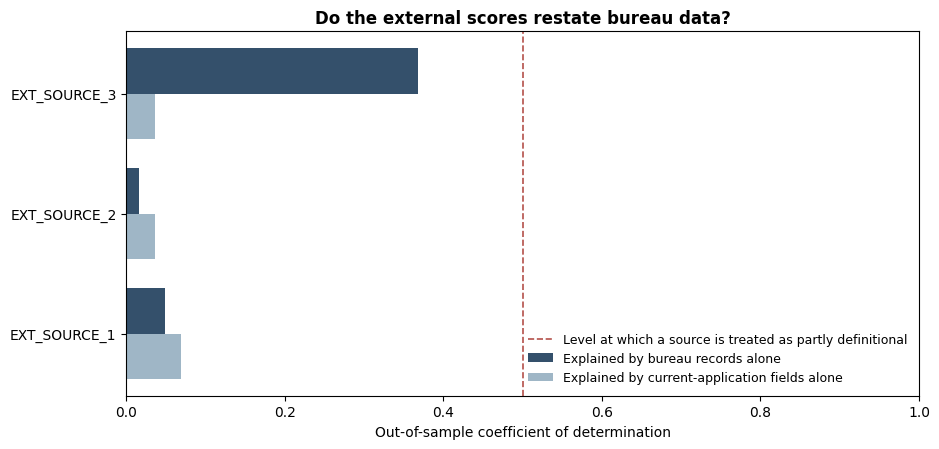

In [9]:
# ------------------------------- provenance test for the external scores
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

BUREAU_FIELDS = [
    'BUREAU_COUNT', 'BUREAU_ACTIVE_RATIO', 'BUREAU_DEBT_TO_CREDIT_RATIO',
    'BUREAU_DAYS_CREDIT_MEAN', 'BUREAU_BB_DPD_RATIO_MEAN',
    'BUREAU_BB_SEVERE_DPD_MEAN', 'AMT_REQ_CREDIT_BUREAU_YEAR',
]
APPLICATION_FIELDS = [
    'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY',
    'CREDIT_TO_INCOME', 'ANNUITY_TO_INCOME',
]
PROVENANCE_SAMPLE = 80000

def explained_variance(score_column, predictors, observed_mask):
    """Out-of-sample R-squared for predicting an observed score from one source."""
    usable = [c for c in predictors if c in df_all.columns]
    frame = df_all.loc[observed_mask, usable].replace([np.inf, -np.inf], np.nan)
    target = df_all.loc[observed_mask, score_column]
    keep = target.notna()
    frame, target = frame[keep], target[keep]
    if len(frame) > PROVENANCE_SAMPLE:
        frame = frame.sample(PROVENANCE_SAMPLE, random_state=RANDOM_SEED)
        target = target.loc[frame.index]
    fit_x, holdout_x, fit_y, holdout_y = train_test_split(
        frame, target, test_size=0.3, random_state=RANDOM_SEED)
    model = HistGradientBoostingRegressor(
        max_iter=200, learning_rate=0.1, random_state=RANDOM_SEED)
    model.fit(fit_x, fit_y)
    return float(r2_score(holdout_y, model.predict(holdout_x))), int(len(frame))

provenance_rows = []
for score in ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']:
    source_col = f'SOURCE_{score}' if f'SOURCE_{score}' in df_all.columns else score
    flag_col = f'FLAG_{score}_MISSING'
    observed = df_all[flag_col].eq(0) if flag_col in df_all.columns else df_all[source_col].notna()
    bureau_r2, n_used = explained_variance(source_col, BUREAU_FIELDS, observed)
    app_r2, _ = explained_variance(source_col, APPLICATION_FIELDS, observed)
    provenance_rows.append({
        'score': score,
        'observed_applications': int(observed.sum()),
        'applications_modelled': n_used,
        'bureau_only_r2': bureau_r2,
        'application_only_r2': app_r2,
        'bureau_advantage': bureau_r2 - app_r2,
    })
provenance = pd.DataFrame(provenance_rows)
provenance['independence_verdict'] = np.where(
    provenance['bureau_only_r2'] >= 0.50,
    'Substantially reconstructible from bureau data; treat bureau-to-score rules as partly definitional',
    np.where(provenance['bureau_only_r2'] >= 0.25,
             'Partly overlapping with bureau data; report the overlap as a caveat',
             'Not reconstructible from bureau data; the two sources carry different information'))
provenance.to_csv(OUT_DIR / 'external_score_provenance.csv', index=False)

print('How much of each observed external score is explained by one source alone')
print('(out-of-sample R-squared, gradient-boosted, scores never imputed):')
print(provenance[['score', 'observed_applications', 'bureau_only_r2',
                  'application_only_r2', 'bureau_advantage']].round(4).to_string(index=False))
print()
for _, row in provenance.iterrows():
    print(f"{row['score']}: {row['independence_verdict']}")

worst = provenance.loc[provenance['bureau_only_r2'].idxmax()]
print()
print(f"Highest bureau explanatory power: {worst['score']} at R-squared "
      f"{worst['bureau_only_r2']:.3f}, against {worst['application_only_r2']:.3f} from "
      "application fields alone.")
print('An R-squared near zero means bureau aggregates cannot reconstruct the score, so a')
print('rule joining the two connects genuinely different evidence. A high value would mean')
print('the rule restates how the score is built, and the screen below would be counting one')
print('source twice.')

fig, ax = plt.subplots(figsize=(9.5, 4.6))
y = np.arange(len(provenance))
ax.barh(y + .19, provenance['bureau_only_r2'], height=.38, color='#34506B',
        label='Explained by bureau records alone')
ax.barh(y - .19, provenance['application_only_r2'], height=.38, color='#9FB6C6',
        label='Explained by current-application fields alone')
ax.axvline(.50, color='#B4504A', linestyle='--', linewidth=1.2,
           label='Level at which a source is treated as partly definitional')
ax.set_yticks(y); ax.set_yticklabels(provenance['score'])
ax.set_xlabel('Out-of-sample coefficient of determination')
ax.set_xlim(0, 1)
ax.set_title('Do the external scores restate bureau data?', fontweight='bold')
ax.legend(frameon=False, fontsize=9, loc='lower right')
plt.tight_layout()
savefig_atomic(OUT_DIR / 'plot_external_score_provenance.png', dpi=170, bbox_inches='tight')
plt.show()


## 8. Keep only rules that add business information

The screen removes arithmetic identities, missingness created by the table
schema, repeated views of the same bureau fields, and count relationships
inside previous applications. It also rejects three-item rules when the
second condition barely improves on a simpler rule. The final shortlist
must connect independent evidence sources and show either converging concern,
consistent lower-concern evidence, or a conflict that a reviewer can resolve.

Rules are de-duplicated across directions and segment contexts. The display is
capped at 12 patterns for a ten-minute presentation, with no quota per segment.
If fewer than 10 unique patterns survive, the notebook exports that shortfall
instead of filling the table with weak rules.


In [10]:
def rule_items(rule):
    left, right = str(rule).split(' -> ', 1)
    clean = lambda text: {x.strip() for x in text.strip('{}').split(',') if x.strip()}
    return clean(left), clean(right)

def jaccard(rule1, rule2):
    a = set().union(*rule_items(rule1)); b = set().union(*rule_items(rule2))
    return len(a & b) / max(len(a | b), 1)

def redundant_with(rule, selected_rows):
    antecedents, _ = rule_items(rule)
    for selected_row in selected_rows:
        other_rule = selected_row['rule_str']
        other_antecedents, _ = rule_items(other_rule)
        if antecedents == other_antecedents:
            return True
        if jaccard(rule, other_rule) > JACCARD_REDUNDANCY:
            return True
    return False

history_families = {
    'repayment_history', 'card_use', 'credit_file', 'bureau_debt',
    'previous_depth', 'previous_outcome', 'external_score',
}
algebraic_families = {'income', 'credit_size', 'leverage', 'burden'}
deterministic_item_groups = [
    {'previous_none', 'previous_outcome_not_observed'},
    {'credit_file_none', 'bureau_debt_not_observed'},
]
SOURCE_GROUP = {
    'income': 'current_application_affordability',
    'credit_size': 'current_application_affordability',
    'leverage': 'current_application_affordability',
    'burden': 'current_application_affordability',
    'external_score': 'external_score',
    'repayment_history': 'instalment_history',
    'card_use': 'card_history',
    'credit_file': 'bureau_history',
    'bureau_debt': 'bureau_history',
    'previous_depth': 'previous_application',
    'previous_outcome': 'previous_application',
}

# Missingness that propagates along a foreign key.
#
# installments_payments, credit_card_balance and POS_CASH_balance are all
# CHILD tables of previous_application, keyed on SK_ID_PREV. An applicant
# with no previous application therefore cannot have instalment, card, or
# POS rows attached to one - their absences co-occur by construction, not
# because independent reporting systems happen to agree.
#
# This is why six of the fifteen previous final rules carried lift between
# 11.3 and 17.46 while saying nothing about independent application behaviour. The old
# filter caught same-TABLE missingness identities but had no notion of the
# schema, so these passed as genuine discoveries.
#
# A rule is rejected when its consequent is one of these absences AND an
# antecedent is another: the implication is then structural, and any extra
# antecedent term is decoration. A rule like {income_q1} -> {no repayment
# history} still survives, because that one genuinely describes WHO lacks
# history rather than restating the join.
previous_application_descendant_absence = {
    'previous_none', 'previous_outcome_not_observed',
    'repayment_not_observed', 'card_history_not_observed',
}

def nontrivial_reason(rule):
    antecedents, consequents = rule_items(rule)
    if len(consequents) != 1 or len(antecedents) > 2:
        return 'not_compact_single_consequent'
    families = {ITEM_FAMILY.get(item, 'unknown') for item in antecedents | consequents}
    items = antecedents | consequents
    if any(group.issubset(items) for group in deterministic_item_groups):
        return 'same_source_missingness_identity'
    if len(items & previous_application_descendant_absence) >= 2:
        return 'schema_induced_missingness_identity'
    if {'previous_depth', 'previous_outcome'}.issubset(families):
        return 'nested_previous_count_definition'
    if {'credit_file', 'bureau_debt'}.issubset(families):
        return 'same_bureau_derived_family'
    if any(str(item).startswith('cluster_') for item in items):
        return 'restates_cluster_definition'
    if len(families) == 1:
        return 'same_family_restatement'
    # Two or more affordability families in one rule is a restatement, not a
    # finding. income, credit_size, leverage and burden are four vocabularies
    # over three raw quantities: leverage IS credit/income and burden IS
    # annuity/income, so any rule joining two of them is partly definitional.
    #
    # The old test only fired when EVERY family was affordability-related, so
    # attaching one behavioural item was enough to smuggle an arithmetic core
    # through - {credit_small, repayment_serious_late} -> {leverage_under_3x}
    # scored lift 1.91 while the predictive work was done entirely by the
    # credit/leverage link. Thirteen of eighteen surviving rules had this
    # shape.
    #
    # Requiring at most one affordability item per rule forces the remaining
    # antecedents to earn their place from behaviour or history.
    if len(families & algebraic_families) >= 2:
        return 'algebraic_financial_identity'
    source_groups = {SOURCE_GROUP.get(family, 'unknown') for family in families}
    if len(source_groups) < 2:
        return 'same_source_restatement'
    if not (families & history_families):
        return 'no_behavior_or_history_signal'
    return 'accepted_cross_source'

global_candidates = rule_groups.copy()
global_candidates['target_cluster'] = global_candidates['rule_str'].map(
    lambda rule: next((item for item in rule_items(rule)[0] | rule_items(rule)[1]
                       if str(item).startswith('cluster_')), 'global'))
segment_candidates = rules_per_cluster.copy()
segment_candidates['n_algos'] = 1
segment_candidates['appears_in'] = 'fpgrowth_segment'
segment_candidates['is_consistent'] = False
segment_candidates['target_cluster'] = segment_candidates['context']
candidate_pool = pd.concat([global_candidates, segment_candidates], ignore_index=True, sort=False)
candidate_pool['selection_reason'] = candidate_pool['rule_str'].map(nontrivial_reason)
candidate_pool['families'] = candidate_pool['rule_str'].map(
    lambda rule: sorted({ITEM_FAMILY.get(item, 'unknown') for side in rule_items(rule) for item in side}))
candidate_pool['source_signature'] = candidate_pool['families'].map(
    lambda families: '+'.join(sorted({SOURCE_GROUP.get(family, 'unknown') for family in families})))
candidate_pool['selection_reason'].value_counts().rename_axis('reason').reset_index(name='rules').to_csv(
    OUT_DIR / 'rule_rejection_audit.csv', index=False)
cross_source = candidate_pool[candidate_pool['selection_reason'].eq('accepted_cross_source')].copy()

# The second screen asks whether the remaining association is useful in a
# manual credit review. Count depth and missingness remain valid portfolio
# facts, but they do not qualify as independent borrower findings here.
ADVERSE_EVIDENCE = {
    'external_score_weak', 'repayment_some_late', 'repayment_serious_late',
    'card_utilisation_high', 'bureau_debt_moderate', 'bureau_debt_high',
    'previous_refusals_repeated', 'previous_outcome_mixed',
    'leverage_over_6x', 'burden_over_35pct',
}
SUPPORTIVE_EVIDENCE = {
    'external_score_strong', 'repayment_clean_observed', 'bureau_debt_low',
    'leverage_under_3x', 'burden_under_20pct', 'previous_approval_high',
}
DEPTH_OR_ABSENCE = {
    'previous_none', 'previous_one', 'previous_two_to_four', 'previous_deep',
    'previous_outcome_not_observed', 'repayment_not_observed',
    'card_history_not_observed', 'credit_file_none', 'bureau_debt_not_observed',
    'external_score_unavailable',
}

def business_theme(rule):
    antecedents, consequents = rule_items(rule)
    items = antecedents | consequents
    if items & DEPTH_OR_ABSENCE:
        return 'history_depth_or_missingness_context'
    signal_items = ADVERSE_EVIDENCE | SUPPORTIVE_EVIDENCE
    if not consequents.issubset(signal_items) or not (antecedents & signal_items):
        return 'low_information_band'
    adverse_n = len(items & ADVERSE_EVIDENCE)
    supportive_n = len(items & SUPPORTIVE_EVIDENCE)
    if adverse_n and supportive_n:
        return 'mixed_evidence_reconcile'
    if adverse_n >= 2:
        return 'adverse_convergence'
    if supportive_n >= 2:
        return 'supportive_convergence'
    return 'low_information_band'

# A two-condition rule is decorative when a one-condition rule with the same
# consequent already exists in the same population and the extra condition
# adds less than 3 percentage points of confidence and 0.08 of lift. These are
# presentation-screen settings, not lending cutoffs.
subset_lookup = {}
for _, row in cross_source.iterrows():
    antecedents, consequents = rule_items(row['rule_str'])
    subset_lookup[(row['target_cluster'], frozenset(consequents), frozenset(antecedents))] = row

def decorative_antecedent(row):
    antecedents, consequents = rule_items(row['rule_str'])
    if len(antecedents) != 2:
        return False
    for item in antecedents:
        simpler = subset_lookup.get((
            row['target_cluster'], frozenset(consequents), frozenset({item})))
        if simpler is None:
            continue
        confidence_gain = row['confidence'] - simpler['confidence']
        lift_gain = row['lift'] - simpler['lift']
        if confidence_gain < .03 and lift_gain < .08:
            return True
    return False

cross_source['business_screen'] = cross_source['rule_str'].map(business_theme)
cross_source['decorative_antecedent'] = cross_source.apply(decorative_antecedent, axis=1)
cross_source.loc[cross_source['decorative_antecedent'], 'business_screen'] = 'decorative_antecedent'
cross_source['business_screen'].value_counts().rename_axis('reason').reset_index(name='rules').to_csv(
    OUT_DIR / 'rule_business_screen_audit.csv', index=False)
candidate_pool.merge(
    cross_source[['context', 'rule_str', 'business_screen', 'decorative_antecedent']],
    on=['context', 'rule_str'], how='left', validate='one_to_one'
).to_csv(OUT_DIR / 'rule_candidate_screen_audit.csv', index=False)

BUSINESS_THEMES = {
    'adverse_convergence': 'Concern signals converge',
    'supportive_convergence': 'Lower-concern evidence agrees',
    'mixed_evidence_reconcile': 'Evidence conflict to reconcile',
}
business_candidates = cross_source[
    cross_source['business_screen'].isin(BUSINESS_THEMES)
].copy()
business_candidates['pattern_key'] = business_candidates['rule_str'].map(
    lambda rule: ' | '.join(sorted(set().union(*rule_items(rule)))))
business_candidates['consequent_key'] = business_candidates['rule_str'].map(
    lambda rule: next(iter(rule_items(rule)[1])))
business_candidates['antecedent_count'] = business_candidates['rule_str'].map(
    lambda rule: len(rule_items(rule)[0]))
business_candidates['business_score'] = (
    (business_candidates['lift'] - 1)
    * business_candidates['confidence']
    * np.sqrt(business_candidates['support'])
    * np.where(business_candidates['antecedent_count'].eq(1), 1.10, 1.0)
)

# If a readable two-item business rule exists, a three-item superset remains
# in the audit but does not take a second display slot for the same core idea.
def has_business_subset(row):
    row_items = set().union(*rule_items(row['rule_str']))
    if len(row_items) != 3:
        return False
    same_context = business_candidates[
        business_candidates['target_cluster'].eq(row['target_cluster'])]
    for other_rule in same_context['rule_str']:
        other_items = set().union(*rule_items(other_rule))
        if len(other_items) == 2 and other_items.issubset(row_items):
            return True
    return False

business_candidates['display_redundant_superpattern'] = business_candidates.apply(
    has_business_subset, axis=1)
display_pool = business_candidates[
    ~business_candidates['display_redundant_superpattern']
].sort_values(
    ['business_score', 'lift', 'confidence', 'support_count'], ascending=False
).drop_duplicates('pattern_key')

# These caps protect variety in a short presentation. They do not change the
# mined candidates and do not imply that one source or segment is riskier.
MAX_FINAL_RULES = 12
ASSIGNMENT_MINIMUM = 10
selected = []
source_counts, context_counts, consequent_counts = defaultdict(int), defaultdict(int), defaultdict(int)
for _, row in display_pool.iterrows():
    if len(selected) >= MAX_FINAL_RULES:
        break
    if source_counts[row['source_signature']] >= 3:
        continue
    if context_counts[row['target_cluster']] >= 3:
        continue
    if consequent_counts[row['consequent_key']] >= 3:
        continue
    if any(jaccard(row['rule_str'], chosen['rule_str']) > JACCARD_REDUNDANCY for chosen in selected):
        continue
    selected.append(row.to_dict())
    source_counts[row['source_signature']] += 1
    context_counts[row['target_cluster']] += 1
    consequent_counts[row['consequent_key']] += 1

top_rules = pd.DataFrame(selected).reset_index(drop=True)
if top_rules.empty:
    top_rules = display_pool.head(0).copy()
top_rules['rank'] = np.arange(1, len(top_rules) + 1)
top_rules['metric_scope'] = np.where(
    top_rules['context'].eq('Portfolio-wide'),
    'Full portfolio. Three algorithms enumerated the same rule.',
    'Within-segment FP-Growth. Metrics use the segment denominator.')
assert top_rules['pattern_key'].is_unique
top_rules.to_csv(OUT_DIR / 'rule_table_final.csv', index=False)
status = pd.DataFrame([{
    'business_signal_candidates': len(business_candidates),
    'unique_business_patterns': business_candidates['pattern_key'].nunique(),
    'selected_unique_patterns': len(top_rules),
    'assignment_minimum': ASSIGNMENT_MINIMUM,
    'meets_assignment_minimum': len(top_rules) >= ASSIGNMENT_MINIMUM,
    'selection_note': (
        'Minimum met without schema, arithmetic, count-definition, or decorative rules'
        if len(top_rules) >= ASSIGNMENT_MINIMUM
        else 'Honest shortfall: fewer than ten defensible unique patterns survived'
    ),
}])
status.to_csv(OUT_DIR / 'rule_shortlist_status.csv', index=False)
if len(top_rules) < ASSIGNMENT_MINIMUM:
    print(f'WARNING: only {len(top_rules)} defensible unique patterns survived; no weak rules were added.')
print(top_rules[['rank','target_cluster','rule_str','support_count','support','confidence','lift','metric_scope']].to_string(index=False))


 rank            target_cluster                                                                     rule_str  support_count  support  confidence     lift                                                   metric_scope
    1    cluster_0_history_rich                                 {external_score_strong} -> {bureau_debt_low}           8790 0.170303    0.643108 1.213075 Within-segment FP-Growth. Metrics use the segment denominator.
    2  cluster_4_card_intensive                             {card_utilisation_high} -> {external_score_weak}           5618 0.102999    0.470598 1.362364 Within-segment FP-Growth. Metrics use the segment denominator.
    3                    global                        {previous_refusals_repeated} -> {repayment_some_late}          22151 0.062177    0.600819 1.351046     Full portfolio. Three algorithms enumerated the same rule.
    4 cluster_2_lower_intensity                                  {bureau_debt_high} -> {external_score_weak}           4313 0.036205

## 9. Business views of the shortlisted patterns

These charts answer three practical questions: which evidence sources line up,
how large the observed difference is relative to the same population, and where
a reviewer should verify conflicting or reinforcing evidence. The algorithm-count
chart remains only as an enumeration check; it is not a business finding.

In [11]:
from matplotlib.patches import Patch

ITEM_LABELS = {
    'income_q1': 'income in the lowest portfolio quartile',
    'income_q2': 'income in the lower-middle portfolio quartile',
    'income_q3': 'income in the upper-middle portfolio quartile',
    'income_q4': 'income in the highest portfolio quartile',
    'credit_small': 'current-loan credit amount in the lower portfolio third',
    'credit_medium': 'current-loan credit amount in the middle portfolio third',
    'credit_large': 'current-loan credit amount in the upper portfolio third',
    'leverage_under_3x': 'current-loan credit amount below 3 times income',
    'leverage_3_to_6x': 'current-loan credit amount between 3 and 6 times income',
    'leverage_over_6x': 'current-loan credit amount above 6 times income',
    'burden_under_20pct': 'annuity below 20% of income',
    'burden_20_to_35pct': 'annuity between 20% and 35% of income',
    'burden_over_35pct': 'annuity above 35% of income',
    'external_score_weak': 'available external scores in the lower band',
    'external_score_middle': 'available external scores in the middle band',
    'external_score_strong': 'available external scores in the upper band',
    'repayment_clean_observed': 'observed instalments with no recorded lateness',
    'repayment_some_late': 'observed instalments with some recorded lateness',
    'repayment_serious_late': 'observed instalments with lateness above 30 days',
    'card_utilisation_moderate': 'observed average card utilisation below 80%',
    'card_utilisation_high': 'observed average card utilisation of at least 80%',
    'credit_file_thin': 'a thin observed bureau credit file',
    'credit_file_established': 'an established observed bureau credit file',
    'bureau_debt_low': 'bureau debt below 30% of bureau credit',
    'bureau_debt_moderate': 'bureau debt between 30% and 80% of bureau credit',
    'bureau_debt_high': 'bureau debt at least 80% of bureau credit',
    'previous_approval_high': 'at least 75% of prior applications approved',
    'previous_refusals_repeated': 'at least 3 prior applications refused',
    'previous_outcome_mixed': 'a mixed prior-application outcome',
}
SOURCE_LABELS = {
    'current_application_affordability': 'Current application affordability',
    'external_score': 'External scores',
    'instalment_history': 'Instalment history',
    'card_history': 'Card history',
    'bureau_history': 'Bureau history',
    'previous_application': 'Prior applications',
}
THEME_COLORS = {
    'Concern signals converge': '#B4504A',
    'Lower-concern evidence agrees': '#4F7C67',
    'Evidence conflict to reconcile': '#C28A2E',
}

def item_label(item):
    return ITEM_LABELS.get(str(item), str(item).replace('_', ' '))

def rule_label_parts(rule):
    antecedents, consequents = rule_items(rule)
    left = ' and '.join(item_label(x) for x in sorted(antecedents))
    right = ' and '.join(item_label(x) for x in sorted(consequents))
    return left, right

def readable_rule(rule):
    # Keep the token form for downstream compatibility, but remove braces.
    left, right = str(rule).split(' -> ', 1)
    clean = lambda text: str(text).replace('{', '').replace('}', '').strip()
    return f'{clean(left)} → {clean(right)}'

def business_rule_text(rule):
    left, right = rule_label_parts(rule)
    return f'When an application has {left}, it more often also shows {right}'

def rule_source_groups(rule):
    families = {ITEM_FAMILY.get(item, 'unknown') for side in rule_items(rule) for item in side}
    return sorted({SOURCE_GROUP.get(family, 'unknown') for family in families})

def rule_action(rule):
    groups = set(rule_source_groups(rule))
    checks = []
    if 'current_application_affordability' in groups:
        checks.append('recheck documented income, current-loan credit amount, and annuity burden')
    if 'external_score' in groups:
        checks.append('verify available external-score inputs and their reporting date')
    if 'instalment_history' in groups:
        checks.append('inspect late-payment dates, severity, and whether arrears were cured')
    if 'card_history' in groups:
        checks.append('review historical card balances, limits, and payment behaviour')
    if 'bureau_history' in groups:
        checks.append('reconcile bureau balances, credit limits, and reporting dates')
    if 'previous_application' in groups:
        checks.append('review prior Home Credit decisions and recorded refusal reasons')
    if not checks:
        return 'Review the underlying source records.'
    if len(checks) == 1:
        return checks[0].capitalize() + '.'
    return '. Then '.join(check.capitalize() for check in checks) + '.'

def evidence_caveat(row):
    notes = ['Exploratory association only. No outcome column is read anywhere in this project, so this is a co-occurrence pattern, not a causal claim and not a lending decision rule.']
    if row['target_cluster'] != 'global':
        notes.append('Support, confidence, and lift use this segment as the denominator.')
    groups = set(rule_source_groups(row['rule_str']))
    if groups & {'instalment_history', 'card_history', 'previous_application'}:
        notes.append('These history tables reflect applicants with a past Home Credit relationship; exposure affects what can be observed.')
    return ' '.join(notes)

display_names = {cluster_map[int(r.cluster_id)]: r.segment_name for r in cluster_names_df.itertuples()}
display_names['global'] = 'Portfolio-wide'
rule_view = top_rules.copy()
rule_view['short_rule'] = rule_view['rule_str'].map(readable_rule)
rule_view['business_rule'] = rule_view['rule_str'].map(business_rule_text)
rule_view['Segment'] = rule_view['target_cluster'].map(display_names).fillna('Portfolio-wide')
rule_view['Context'] = np.where(
    rule_view['context'].eq('Portfolio-wide'), 'Portfolio-wide',
    rule_view['context'].map(display_names).fillna(rule_view['context']))
rule_view['condition_count'] = np.rint(
    rule_view['support_count'] / rule_view['confidence']).astype(int)
rule_view['consequent_baseline'] = rule_view['confidence'] / rule_view['lift']
rule_view['uplift_pp'] = 100 * (rule_view['confidence'] - rule_view['consequent_baseline'])
rule_view['business_theme'] = rule_view['business_screen'].map(BUSINESS_THEMES)
rule_view['source_families'] = rule_view['rule_str'].map(
    lambda rule: '; '.join(SOURCE_LABELS.get(x, x) for x in rule_source_groups(rule)))
rule_view['review_action'] = rule_view['rule_str'].map(rule_action)
rule_view['caveat'] = rule_view.apply(evidence_caveat, axis=1)

def why_rule_matters(row):
    condition, evidence = rule_label_parts(row['rule_str'])
    observation = (
        f"In {row['Context']}, {int(row['support_count']):,} of about "
        f"{int(row['condition_count']):,} applications with {condition} also show {evidence}. "
        f"That is {row['confidence']:.1%}, compared with {row['consequent_baseline']:.1%} "
        'in the same population.'
    )
    meaning = {
        'Concern signals converge': 'Several concern signals meet in one review.',
        'Lower-concern evidence agrees': 'The observed lower-concern evidence is internally consistent, but it does not prove a lower chance of payment difficulty.',
        'Evidence conflict to reconcile': 'The evidence points in different directions, so recency and source consistency need checking.',
    }[row['business_theme']]
    return f'{observation} {meaning}'

rule_view['why_it_matters'] = rule_view.apply(why_rule_matters, axis=1)
export_cols = [
    'rank', 'pattern_key', 'rule_str', 'short_rule', 'business_rule', 'Segment',
    'Context', 'context_n', 'condition_count', 'support_count', 'support',
    'consequent_baseline', 'confidence', 'uplift_pp', 'lift', 'business_theme',
    'source_families', 'why_it_matters', 'review_action', 'caveat', 'metric_scope']
# The export happens in the next cell, after the exposure adjustment adds its columns.


## 9b. Exposure standardisation: separating behaviour from opportunity

### The problem this solves

Several items in the vocabulary are **accumulation states**: they record whether something was *ever* observed across a history that keeps growing. `repayment_some_late` is true when at least one instalment out of all instalments on file was late. `previous_refusals_repeated` requires at least three refusals, which forces at least three previous applications.

That creates a trap specific to this dataset. `installments_payments`, `credit_card_balance`, and `POS_CASH_balance` are child tables of `previous_application`, so an applicant with a longer Home Credit relationship contributes more rows to every one of them. Applicants meeting `previous_refusals_repeated` carry a median instalment history far deeper than the portfolio median. More observed instalments mechanically raise the probability that at least one of them was late, whatever the applicant's actual payment behaviour. A rule linking the two would then measure **length of relationship**, not repayment conduct, and a reviewer acting on it would be scrutinising long-standing customers rather than risky ones.

Phase 1 already flagged this exposure asymmetry, and the Limitations section names it. Naming it is not enough: a number that is quoted in the report has to carry the correction.

### The correction

For every shortlisted rule whose consequent is an accumulation state, the notebook computes a **directly standardised confidence**. The rule's own population is split into strata by the depth of the relevant history, the confidence is measured inside each stratum, and the stratum results are then re-weighted to the exposure profile of the whole population rather than the antecedent group's own profile.

The exposure variable is chosen from the consequent's source table, because that is the history whose length governs the chance of observing the consequent at all:

| Consequent family | Exposure variable | Reason |
|---|---|---|
| `repayment_history` | `INST_COUNT` | Lateness is observed per instalment record |
| `previous_depth`, `previous_outcome` | `PREV_COUNT` | Refusals and approvals are observed per previous application |
| `card_use` | `CC_MONTHS_COUNT` | Utilisation is observed per card month |
| `credit_file`, `bureau_debt` | `BUREAU_COUNT` | Bureau states are observed per bureau credit |
| `external_score`, `income`, `credit_size`, `leverage`, `burden` | none | These are single application-time values, so no accumulation can inflate them |

`exposure_adjusted_lift` is the honest headline for an accumulation consequent. Where the adjusted lift stays close to the raw lift, the association survives the correction and describes behaviour. Where it collapses towards 1.0, the raw figure was mostly relationship length and the rule must be reported with the adjusted number in front.


In [12]:
# ------------------------------------------------ exposure standardisation
# The consequent's own source table decides which history length could
# manufacture the association. Application-time values cannot accumulate, so
# they are exempt by construction rather than by assumption.
EXPOSURE_BY_FAMILY = {
    'repayment_history': 'INST_COUNT',
    'previous_depth': 'PREV_COUNT',
    'previous_outcome': 'PREV_COUNT',
    'card_use': 'CC_MONTHS_COUNT',
    'credit_file': 'BUREAU_COUNT',
    'bureau_debt': 'BUREAU_COUNT',
}
EXPOSURE_BANDS = 5

# Band edges come from the whole portfolio so every rule, portfolio-wide or
# within a segment, is corrected against the same exposure scale.
exposure_bands = {}
for column in sorted(set(EXPOSURE_BY_FAMILY.values())):
    values = df_all[column].fillna(0)
    edges = values[values > 0].quantile(np.linspace(0, 1, EXPOSURE_BANDS + 1)).unique()
    edges = np.unique(np.concatenate([[-np.inf, 0.5], edges, [np.inf]]))
    exposure_bands[column] = pd.cut(values, bins=edges, include_lowest=True)
    print(f'{column:18s} -> {exposure_bands[column].cat.categories.size} exposure strata')

def standardise_rule(rule_str, context_label):
    """Direct standardisation of a rule's confidence by history depth.

    Returns raw and adjusted confidence, the shared baseline, and the exposure
    imbalance that made the correction necessary.
    """
    antecedents, consequents = rule_items(rule_str)
    consequent = next(iter(consequents))
    family = ITEM_FAMILY.get(consequent, '')
    exposure_col = EXPOSURE_BY_FAMILY.get(family)

    if context_label == 'global':
        context_mask = pd.Series(True, index=trans_df.index)
    else:
        context_mask = cluster_key.eq(context_label)

    ante_mask = context_mask.copy()
    for item in antecedents:
        ante_mask &= trans_df[ITEM_FAMILY[item]].eq(item)
    cons_mask = trans_df[family].eq(consequent) if family else pd.Series(False, index=trans_df.index)

    raw_conf = float(cons_mask[ante_mask].mean())
    baseline = float(cons_mask[context_mask].mean())

    if exposure_col is None:
        return {
            'exposure_variable': 'none (application-time value)',
            'exposure_adjusted_confidence': raw_conf,
            'exposure_adjusted_lift': raw_conf / baseline if baseline else np.nan,
            'exposure_ratio': 1.0,
            'exposure_strata_used': 0,
            'exposure_sensitive': False,
        }

    bands = exposure_bands[exposure_col]
    weights = bands[context_mask].value_counts(normalize=True, sort=False)
    adjusted_num, weight_used = 0.0, 0.0
    strata_used = 0
    for band, weight in weights.items():
        stratum = context_mask & bands.eq(band)
        in_stratum = stratum & ante_mask
        if not in_stratum.any() or weight == 0:
            continue
        adjusted_num += weight * float(cons_mask[in_stratum].mean())
        weight_used += weight
        strata_used += 1
    adjusted = adjusted_num / weight_used if weight_used else np.nan

    exposure_values = df_all[exposure_col].fillna(0)
    ratio = (exposure_values[ante_mask].mean() /
             exposure_values[context_mask].mean()) if exposure_values[context_mask].mean() else np.nan
    return {
        'exposure_variable': exposure_col,
        'exposure_adjusted_confidence': adjusted,
        'exposure_adjusted_lift': adjusted / baseline if baseline else np.nan,
        'exposure_ratio': ratio,
        'exposure_strata_used': strata_used,
        'exposure_sensitive': True,
    }

adjustments = pd.DataFrame([
    standardise_rule(row['rule_str'], row['target_cluster'])
    for _, row in rule_view.iterrows()
], index=rule_view.index)
rule_view = pd.concat([rule_view, adjustments], axis=1)
rule_view['exposure_bias_share'] = np.where(
    rule_view['lift'] > 1,
    (rule_view['lift'] - rule_view['exposure_adjusted_lift']) / (rule_view['lift'] - 1),
    0.0).clip(0, 1)
rule_view['headline_lift'] = np.where(
    rule_view['exposure_sensitive'],
    rule_view['exposure_adjusted_lift'], rule_view['lift'])
rule_view['exposure_note'] = np.where(
    ~rule_view['exposure_sensitive'],
    'Consequent is an application-time value, so history length cannot inflate it.',
    np.where(
        rule_view['exposure_bias_share'] >= 0.50,
        'Most of the raw lift is explained by how much history was observed; the adjusted figure is the honest one.',
        'The association survives standardisation for history depth.'))

export_cols = export_cols + [
    'exposure_variable', 'exposure_ratio', 'exposure_adjusted_confidence',
    'exposure_adjusted_lift', 'exposure_bias_share', 'headline_lift',
    'exposure_sensitive', 'exposure_note']
rule_view[export_cols].to_csv(OUT_DIR / 'business_rules_final.csv', index=False)
rule_view[['rank', 'short_rule', 'Context', 'confidence', 'lift', 'exposure_variable',
           'exposure_ratio', 'exposure_adjusted_confidence', 'exposure_adjusted_lift',
           'exposure_bias_share']].to_csv(OUT_DIR / 'rule_exposure_adjustment.csv', index=False)

show = rule_view[['rank', 'short_rule', 'lift', 'exposure_variable', 'exposure_ratio',
                  'exposure_adjusted_lift', 'exposure_bias_share']].copy()
show['short_rule'] = show['short_rule'].str.slice(0, 58)
print('Raw versus exposure-standardised lift:')
print(show.round(3).to_string(index=False))

sensitive = rule_view[rule_view['exposure_sensitive']]
print(f'\n{len(sensitive)} of {len(rule_view)} shortlisted rules have an accumulation consequent.')
if len(sensitive):
    heavy = sensitive[sensitive['exposure_bias_share'] >= 0.50]
    print(f'  {len(heavy)} lose at least half their excess lift once history depth is held constant.')
    for _, row in heavy.iterrows():
        print(f"    R{int(row['rank'])}: lift {row['lift']:.3f} -> {row['exposure_adjusted_lift']:.3f} "
              f"({row['exposure_bias_share']:.0%} of the excess was exposure); "
              f"antecedent group carries {row['exposure_ratio']:.2f}x the population's {row['exposure_variable']}")


BUREAU_COUNT       -> 8 exposure strata


CC_MONTHS_COUNT    -> 8 exposure strata
INST_COUNT         -> 8 exposure strata
PREV_COUNT         -> 8 exposure strata


Raw versus exposure-standardised lift:
 rank                                                 short_rule  lift             exposure_variable  exposure_ratio  exposure_adjusted_lift  exposure_bias_share
    1                    external_score_strong → bureau_debt_low 1.213                  BUREAU_COUNT           0.852                   1.242                0.000
    2                card_utilisation_high → external_score_weak 1.362 none (application-time value)           1.000                   1.362                0.000
    3           previous_refusals_repeated → repayment_some_late 1.351                    INST_COUNT           1.589                   1.065                0.815
    4                     bureau_debt_high → external_score_weak 1.475 none (application-time value)           1.000                   1.475                0.000
    5 bureau_debt_moderate, previous_refusals_repeated → externa 1.335 none (application-time value)           1.000                   1.335           

### Null-invariant interestingness, the second thing Lift cannot tell you

Support, Confidence, and Lift are the three measures the assignment requires, and they are all computed above. Lift has a documented weakness that matters at this portfolio size: it is **not null-invariant**. Its value depends on the number of transactions in which neither the condition nor the evidence appears, so two rules with identical co-occurrence behaviour can report different Lift purely because one involves rarer items. With 356,255 transactions and items ranging from 3.4 percent to 70.9 percent prevalence, that is not a theoretical concern.

Two standard null-invariant measures are added here so the shortlist can be read without that distortion:

* **Kulczynski**, the average of the two conditional probabilities, `0.5 * (P(evidence | condition) + P(condition | evidence))`. It ignores the co-absence count entirely. A value near 0.5 means the two items are essentially unrelated; values approaching 1.0 mean they travel together in both directions.
* **Imbalance Ratio**, which measures how lopsided the two directions are. A rule can score a respectable Kulczynski while being almost entirely one-directional, and the Imbalance Ratio is what exposes that. Kulczynski and Imbalance Ratio are designed to be read as a pair.
* **Cosine**, a third null-invariant measure included as a cross-check on Kulczynski.

The business reading is straightforward. A pattern with a high Imbalance Ratio tells a reviewer that the relationship works in one direction only, which changes how it may be used: seeing the condition is informative about the evidence, but seeing the evidence says little about the condition. That distinction is invisible in Lift.


In [13]:
# ------------------------------- null-invariant interestingness measures
# Lift depends on the co-absence count, so it is sensitive to how rare the
# items are. Kulczynski, Imbalance Ratio, and Cosine are not. Han and Kamber
# recommend reading Kulczynski together with Imbalance Ratio, which is how the
# shortlist is presented below.
def null_invariant_measures(rule_str, context_label):
    antecedents, consequents = rule_items(rule_str)
    consequent = next(iter(consequents))
    consequent_family = ITEM_FAMILY.get(consequent, '')

    if context_label == 'global':
        context_mask = pd.Series(True, index=trans_df.index)
    else:
        context_mask = cluster_key.eq(context_label)

    ante_mask = context_mask.copy()
    for item in antecedents:
        ante_mask &= trans_df[ITEM_FAMILY[item]].eq(item)
    cons_mask = context_mask & trans_df[consequent_family].eq(consequent)

    n = int(context_mask.sum())
    sup_a = float(ante_mask.sum()) / n
    sup_b = float(cons_mask.sum()) / n
    sup_ab = float((ante_mask & cons_mask).sum()) / n
    if sup_a <= 0 or sup_b <= 0:
        return {'kulczynski': np.nan, 'imbalance_ratio': np.nan, 'cosine': np.nan}

    conf_a_to_b = sup_ab / sup_a
    conf_b_to_a = sup_ab / sup_b
    union = sup_a + sup_b - sup_ab
    return {
        'kulczynski': 0.5 * (conf_a_to_b + conf_b_to_a),
        'imbalance_ratio': abs(sup_a - sup_b) / union if union > 0 else np.nan,
        'cosine': sup_ab / np.sqrt(sup_a * sup_b),
    }

null_invariant = pd.DataFrame([
    null_invariant_measures(row['rule_str'], row['target_cluster'])
    for _, row in rule_view.iterrows()
], index=rule_view.index)
# mlxtend 0.23+ already emits a `kulczynski` column computed in the mining
# context. Ours is computed against each rule's own reported context, which is
# the denominator this report quotes, so the mined copy is replaced rather than
# duplicated. A duplicate name would silently turn every later lookup into a
# two-column frame.
rule_view = rule_view.drop(
    columns=[c for c in null_invariant.columns if c in rule_view.columns])
rule_view = pd.concat([rule_view, null_invariant], axis=1)
rule_view['direction_note'] = np.where(
    rule_view['imbalance_ratio'] >= 0.50,
    'Strongly one-directional: the condition is informative about the evidence, '
    'but seeing the evidence says little about the condition.',
    np.where(rule_view['imbalance_ratio'] >= 0.25,
             'Moderately one-directional; read the condition as the entry point.',
             'Balanced: the two states are similarly informative about each other.'))

export_cols = export_cols + ['kulczynski', 'imbalance_ratio', 'cosine', 'direction_note']
rule_view[export_cols].to_csv(OUT_DIR / 'business_rules_final.csv', index=False)
rule_view[['rank', 'short_rule', 'Context', 'support', 'confidence', 'lift',
           'exposure_adjusted_lift', 'kulczynski', 'imbalance_ratio', 'cosine']].to_csv(
    OUT_DIR / 'rule_interestingness_measures.csv', index=False)

show = rule_view[['rank', 'lift', 'exposure_adjusted_lift', 'kulczynski',
                  'imbalance_ratio', 'cosine']].copy()
print('Required measures beside the null-invariant ones:')
print(show.round(3).to_string(index=False))

balanced = rule_view[rule_view['imbalance_ratio'] < 0.25]
lopsided = rule_view[rule_view['imbalance_ratio'] >= 0.50]
print(f'\nKulczynski range: {rule_view.kulczynski.min():.3f} to {rule_view.kulczynski.max():.3f} '
      '(0.5 means the two states are unrelated).')
print(f'Balanced patterns (imbalance below 0.25): {len(balanced)} of {len(rule_view)}.')
print(f'Strongly one-directional (imbalance at or above 0.50): {len(lopsided)}.')
if len(lopsided):
    for _, row in lopsided.iterrows():
        print(f"  R{int(row['rank'])}: Kulczynski {row['kulczynski']:.3f}, "
              f"imbalance {row['imbalance_ratio']:.3f}. {row['direction_note']}")
print('\nNone of the shortlisted patterns is rescued by a null-invariant measure: every')
print('Kulczynski sits in the moderate band, which agrees with the modest Lift ceiling and')
print('confirms that the strong associations in this portfolio were the definitional ones')
print('already removed by the screening in Section 8.')


Required measures beside the null-invariant ones:
 rank  lift  exposure_adjusted_lift  kulczynski  imbalance_ratio  cosine
    1 1.213                   1.242       0.482            0.425   0.455
    2 1.362                   1.362       0.384            0.274   0.375
    3 1.351                   1.065       0.370            0.702   0.290
    4 1.475                   1.475       0.327            0.771   0.231
    5 1.335                   1.335       0.373            0.469   0.342
    6 1.238                   1.272       0.373            0.382   0.354
    7 1.237                   1.213       0.406            0.126   0.404
    8 1.323                   1.323       0.316            0.353   0.301
    9 1.228                   0.977       0.369            0.811   0.246
   10 1.289                   1.289       0.307            0.459   0.281
   11 1.243                   1.243       0.310            0.721   0.233
   12 1.271                   0.939       0.281            0.719   0.210



### Reading the chart

Each rule appears twice: the raw lift the mining produced, and the lift that remains once the antecedent group is standardised to the population's history depth. Rules with no accumulation consequent are shown unchanged, because nothing about them can be inflated by relationship length. The gap between the two bars is the part of the raw association that was opportunity rather than behaviour.


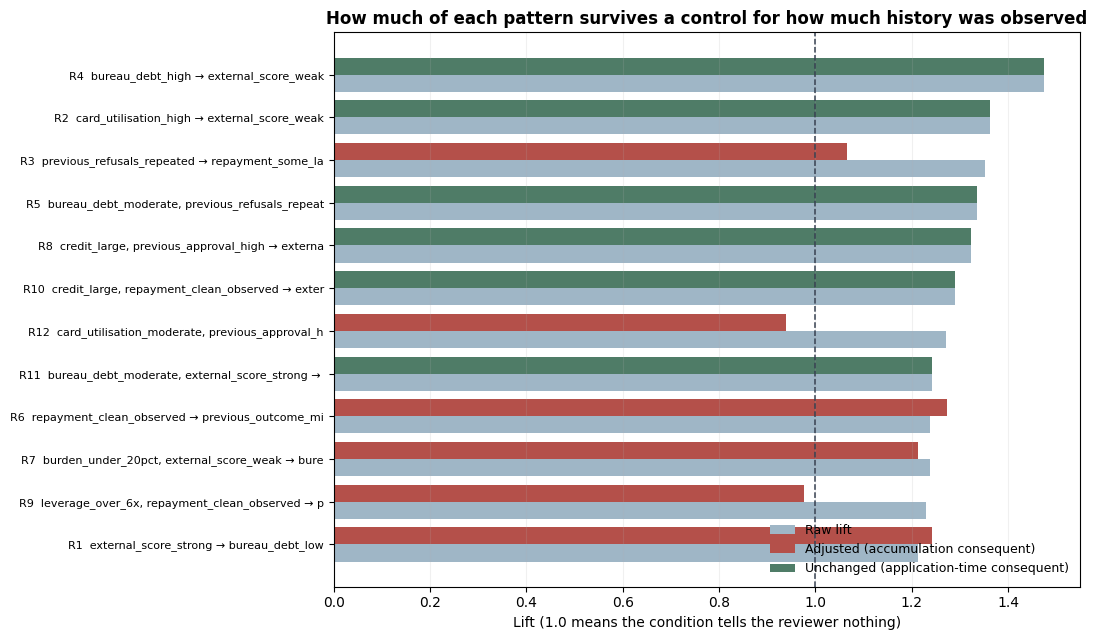

In [14]:
fig, ax = plt.subplots(figsize=(11, 6.5))
order = rule_view.sort_values('lift')
y = np.arange(len(order))
ax.barh(y - .2, order['lift'], height=.4, color='#9FB6C6', label='Raw lift')
ax.barh(y + .2, order['headline_lift'], height=.4,
        color=np.where(order['exposure_sensitive'], '#B4504A', '#4F7C67'),
        label='After standardising for history depth')
ax.axvline(1.0, color='#374151', linewidth=1.1, linestyle='--')
ax.set_yticks(y)
ax.set_yticklabels([f"R{int(r)}  {s[:46]}" for r, s in zip(order['rank'], order['short_rule'])],
                   fontsize=8)
ax.set_xlabel('Lift (1.0 means the condition tells the reviewer nothing)')
ax.set_title('How much of each pattern survives a control for how much history was observed',
             fontweight='bold')
handles = [Patch(facecolor='#9FB6C6', label='Raw lift'),
           Patch(facecolor='#B4504A', label='Adjusted (accumulation consequent)'),
           Patch(facecolor='#4F7C67', label='Unchanged (application-time consequent)')]
ax.legend(handles=handles, loc='lower right', frameon=False, fontsize=9)
ax.grid(alpha=.18, axis='x')
plt.tight_layout()
savefig_atomic(OUT_DIR / 'plot_rule_exposure_adjustment.png', dpi=170, bbox_inches='tight')
plt.show()


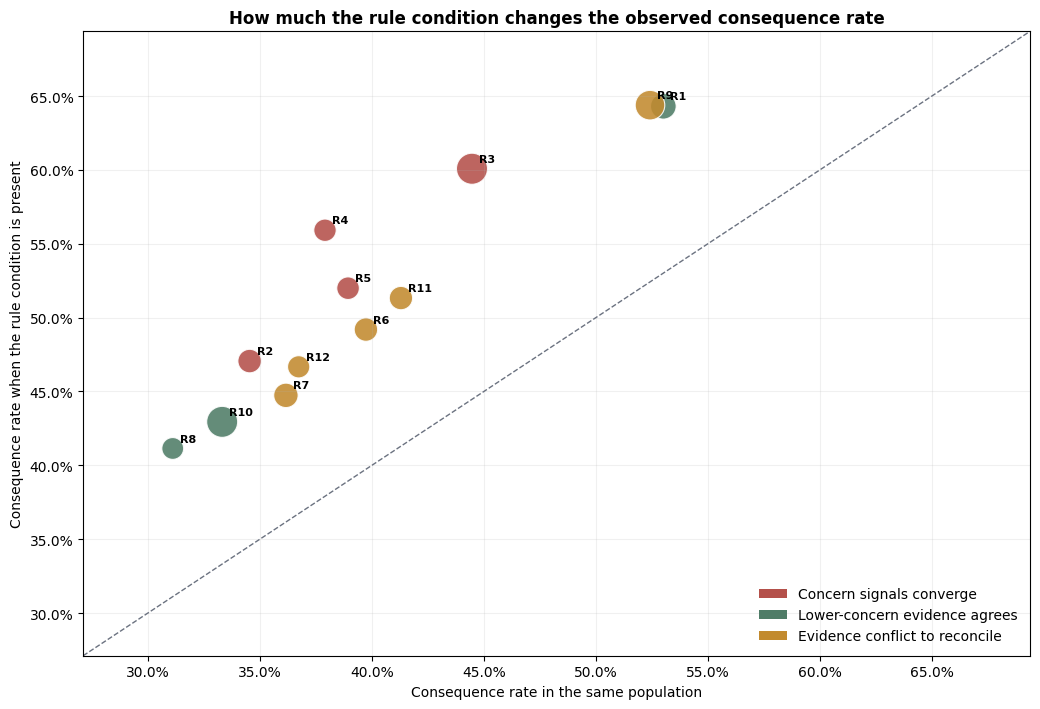

In [15]:
# Compare the consequence rate among applications meeting a rule condition
# with the consequence's baseline rate in that same population.
from matplotlib.ticker import PercentFormatter
fig, ax = plt.subplots(figsize=(10.5, 7.2))
sizes = 70 + 430 * np.sqrt(rule_view['support_count'] / rule_view['support_count'].max())
colours = rule_view['business_theme'].map(THEME_COLORS)
ax.scatter(rule_view['consequent_baseline'], rule_view['confidence'], s=sizes,
           c=colours, edgecolors='white', linewidth=.8, alpha=.88)
axis_min = max(0, min(rule_view['consequent_baseline'].min(), rule_view['confidence'].min()) - .04)
axis_max = min(1, max(rule_view['consequent_baseline'].max(), rule_view['confidence'].max()) + .05)
ax.plot([axis_min, axis_max], [axis_min, axis_max], color='#6B7280', linewidth=1, linestyle='--')
for _, row in rule_view.iterrows():
    ax.annotate(f"R{int(row['rank'])}", (row['consequent_baseline'], row['confidence']),
                xytext=(5, 5), textcoords='offset points', fontsize=8, fontweight='bold')
ax.set_xlim(axis_min, axis_max); ax.set_ylim(axis_min, axis_max)
ax.xaxis.set_major_formatter(PercentFormatter(1)); ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_xlabel('Consequence rate in the same population')
ax.set_ylabel('Consequence rate when the rule condition is present')
ax.set_title('How much the rule condition changes the observed consequence rate', fontweight='bold')
ax.legend(handles=[Patch(facecolor=color, label=theme) for theme, color in THEME_COLORS.items()],
          loc='lower right', frameon=False)
ax.grid(alpha=.18)
plt.tight_layout()
savefig_atomic(OUT_DIR / 'plot_business_condition_vs_baseline.png', dpi=170, bbox_inches='tight')
plt.show()

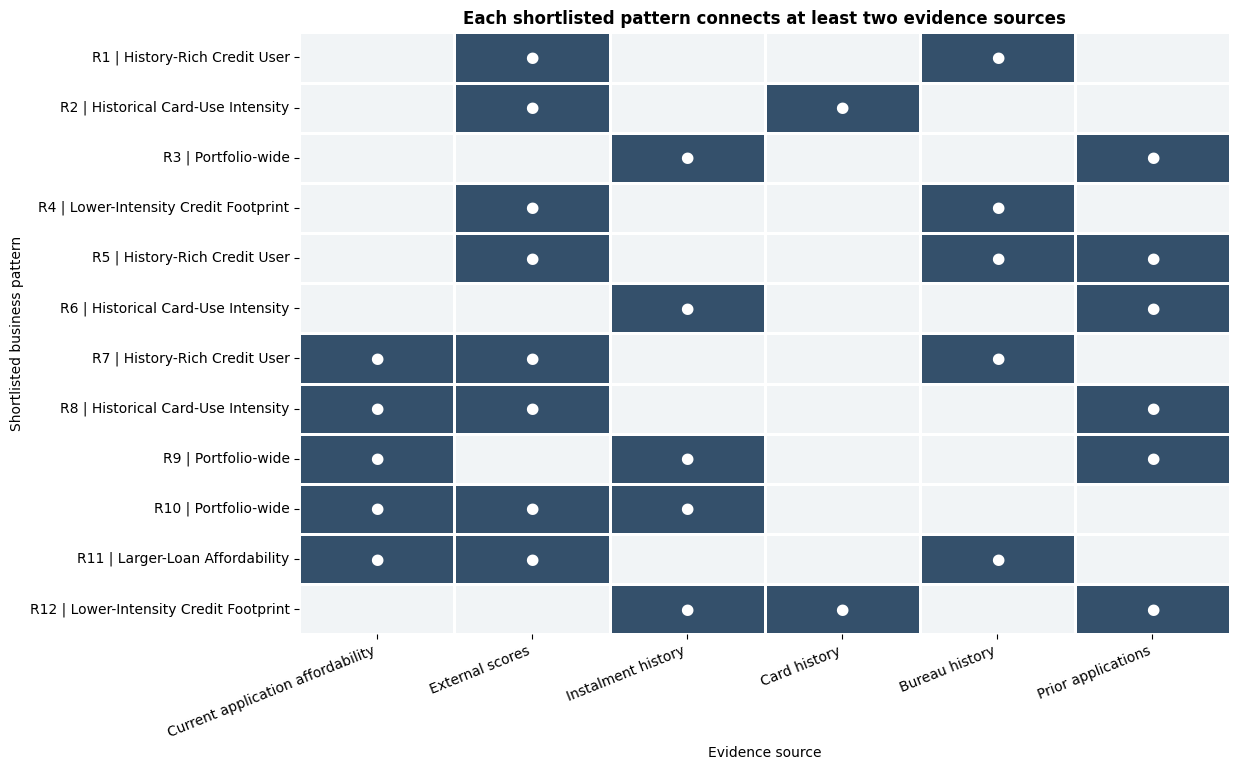

In [16]:
# Evidence-source matrix. Every shortlisted rule must connect at least two
# independently useful review sources.
source_order = list(SOURCE_LABELS)
source_matrix = pd.DataFrame(0, index=rule_view.index, columns=source_order)
for idx, rule in rule_view['rule_str'].items():
    for source in rule_source_groups(rule):
        if source in source_matrix.columns:
            source_matrix.loc[idx, source] = 1
source_matrix.index = [f"R{int(row['rank'])} | {row['Segment']}" for _, row in rule_view.iterrows()]
source_matrix.columns = [SOURCE_LABELS[x] for x in source_order]
fig, ax = plt.subplots(figsize=(12.5, 7.8))
sns.heatmap(source_matrix, cmap=['#F1F4F6', '#34506B'], cbar=False, linewidths=.8,
            linecolor='white', annot=source_matrix.replace({0: '', 1: '●'}), fmt='',
            annot_kws={'fontsize': 11}, ax=ax)
ax.set_xlabel('Evidence source'); ax.set_ylabel('Shortlisted business pattern')
ax.set_title('Each shortlisted pattern connects at least two evidence sources', fontweight='bold')
plt.xticks(rotation=22, ha='right'); plt.yticks(rotation=0)
plt.tight_layout()
savefig_atomic(OUT_DIR / 'plot_rule_evidence_matrix.png', dpi=170, bbox_inches='tight')
plt.show()


In [17]:
# ------------------------------------------------- item catalogue for the network view
# The dashboard draws a rule network. Rather than re-deriving item semantics
# there, Phase 3 publishes the mapping it actually mined with: every item, the
# family it belongs to, the evidence source that family represents, and the
# readable label already used in this notebook. One source of truth means the
# network graph cannot drift from the rule table beside it.
catalog_rows = []
for item, family in ITEM_FAMILY.items():
    catalog_rows.append({
        'item': item,
        'family': family,
        'source_group': SOURCE_GROUP.get(family, 'unknown'),
        'source_label': SOURCE_LABELS.get(SOURCE_GROUP.get(family, ''), 'Other'),
        'readable_label': ITEM_LABELS.get(item, str(item).replace('_', ' ')),
        'evidence_direction': (
            'concern' if item in ADVERSE_EVIDENCE
            else 'supportive' if item in SUPPORTIVE_EVIDENCE
            else 'depth or absence' if item in DEPTH_OR_ABSENCE
            else 'neutral band'),
        'portfolio_share': float(trans_df.eq(item).any(axis=1).mean()),
    })
item_catalog = pd.DataFrame(catalog_rows).sort_values(['source_group', 'family', 'item'])
item_catalog.to_csv(OUT_DIR / 'rule_item_catalog.csv', index=False)
print(f'Saved rule_item_catalog.csv ({len(item_catalog)} items across '
      f'{item_catalog["source_group"].nunique()} evidence sources)')

# Edge list for the network: one row per shortlisted rule, already resolved to
# item level so the dashboard does no parsing.
edge_rows = []
for _, row in rule_view.iterrows():
    antecedents, consequents = rule_items(row['rule_str'])
    consequent = next(iter(consequents))
    for antecedent in sorted(antecedents):
        edge_rows.append({
            'rank': int(row['rank']),
            'antecedent': antecedent,
            'consequent': consequent,
            'antecedent_source': SOURCE_GROUP.get(ITEM_FAMILY.get(antecedent, ''), 'unknown'),
            'consequent_source': SOURCE_GROUP.get(ITEM_FAMILY.get(consequent, ''), 'unknown'),
            'support': float(row['support']),
            'support_count': int(row['support_count']),
            'confidence': float(row['confidence']),
            'lift': float(row['lift']),
            'headline_lift': float(row['headline_lift']),
            'exposure_sensitive': bool(row['exposure_sensitive']),
            'business_theme': row['business_theme'],
            'Context': row['Context'],
            'antecedent_count': len(antecedents),
        })
rule_edges = pd.DataFrame(edge_rows)
rule_edges['crosses_source'] = rule_edges['antecedent_source'].ne(rule_edges['consequent_source'])
rule_edges.to_csv(OUT_DIR / 'rule_network_edges.csv', index=False)
print(f'Saved rule_network_edges.csv ({len(rule_edges)} edges from {rule_edges["rank"].nunique()} rules)')
print(f'Edges connecting two different evidence sources: '
      f'{int(rule_edges["crosses_source"].sum())} of {len(rule_edges)}')


Saved rule_item_catalog.csv (40 items across 6 evidence sources)
Saved rule_network_edges.csv (19 edges from 12 rules)
Edges connecting two different evidence sources: 19 of 19


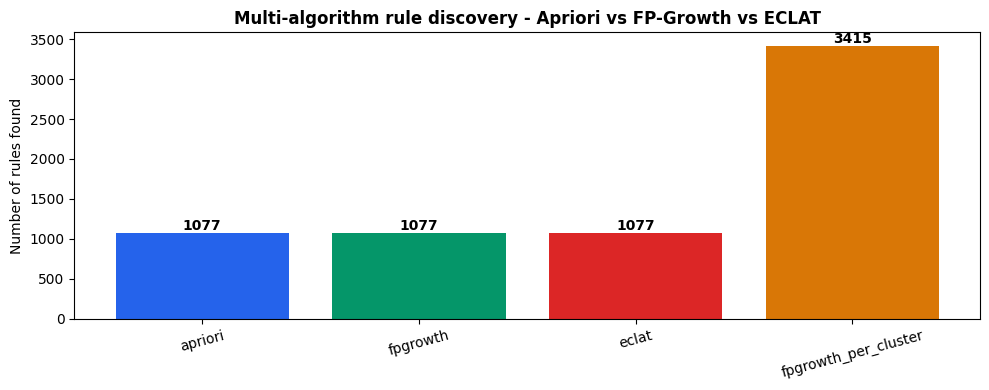

In [18]:
# Algorithm overlap bar
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(algo_df['algorithm_name'], algo_df['Rules'], color=['#2563EB','#059669','#DC2626','#D97706'][:len(algo_df)])
ax.set_ylabel('Number of rules found')
ax.set_title('Multi-algorithm rule discovery - Apriori vs FP-Growth vs ECLAT', fontweight='bold')
for i, v in enumerate(algo_df['Rules']):
    ax.text(i, v + max(algo_df['Rules'])*0.01, f'{v}', ha='center', fontsize=10, fontweight='bold')
plt.xticks(rotation=15)
plt.tight_layout()
savefig_atomic(OUT_DIR / 'plot_algo_comparison.png', dpi=150)
plt.show()

---
Phase 3 done. The artefacts are in `results/phase3_association/`.